In [3]:
%pip install pandas numpy matplotlib seaborn scipy

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.8 MB 10.9 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.8 MB 11.6 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.8 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.8 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 10.8 MB/s  0:00:00
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ------- -------------------------------- 2.4/12.7 MB 11.9 MB/s eta 0:00:01
   --------------- ------------------------ 5.0/12.7 MB 11.8 MB/s eta 0:00:01
   ----------------------- ---------------- 7.6/12.7 MB 11.9 MB/s eta 0:00:01
   ------------------------------- -------- 10.0/12.7 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.7 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------- 12.7/12.7 MB 11.0 MB/s  0:00:01
   --------

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
orders = pd.read_csv('../Data/raw_data/olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
customers = pd.read_csv('../Data/raw_data/olist_customers_dataset.csv')
order_items = pd.read_csv('../Data/raw_data/olist_order_items_dataset.csv')
payments = pd.read_csv('../Data/raw_data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../Data/raw_data/olist_order_reviews_dataset.csv')
products = pd.read_csv('../Data/raw_data/olist_products_dataset.csv')
sellers = pd.read_csv('../Data/raw_data/olist_sellers_dataset.csv')
translation = pd.read_csv('../Data/raw_data/product_category_name_translation.csv')

print('Data loaded!')

Data loaded!


In [7]:
tables = {
    'orders': orders,
    'customers': customers,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'translation': translation
}

for name, df in tables.items():
    print(f'{name:12s} rows={df.shape[0]:>7,}  cols={df.shape[1]}')

orders.head()

orders       rows= 99,441  cols=8
customers    rows= 99,441  cols=5
order_items  rows=112,650  cols=7
payments     rows=103,886  cols=5
reviews      rows= 99,224  cols=7
products     rows= 32,951  cols=9
sellers      rows=  3,095  cols=4
translation  rows=     71  cols=2


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [8]:
orders.info()
orders['order_status'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [9]:
for name, df in [('orders', orders), ('customers', customers),
                 ('order_items', order_items), ('payments', payments),
                 ('reviews', reviews), ('products', products)]:
    missing = df.isnull().sum()
    if missing.any():
        print(f'\n--- {name} ---')
        print(missing[missing > 0])


--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- products ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [10]:
print('Duplicate order_id in orders   :', orders['order_id'].duplicated().sum())
print('Duplicate customer_id           :', customers['customer_id'].duplicated().sum())
print('Duplicate product_id            :', products['product_id'].duplicated().sum())
print('Duplicate seller_id             :', sellers['seller_id'].duplicated().sum())

Duplicate order_id in orders   : 0
Duplicate customer_id           : 0
Duplicate product_id            : 0
Duplicate seller_id             : 0


In [11]:
delivered = orders[orders['order_status'] == 'delivered'].copy()

delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_purchase_timestamp']
).dt.days

delivered['is_delayed'] = (
    delivered['order_delivered_customer_date'] >
    delivered['order_estimated_delivery_date']
)

delivered['order_month'] = delivered['order_purchase_timestamp'].dt.to_period('M')

print('Delivered orders:', len(delivered))
print('Late delivery %  :', round(delivered['is_delayed'].mean() * 100, 2))
print('Avg delivery days:', round(delivered['delivery_days'].mean(), 1))
delivered[['order_id', 'delivery_days', 'is_delayed', 'order_month']].head()

Delivered orders: 96478
Late delivery %  : 8.11
Avg delivery days: 12.1


,order_id,delivery_days,is_delayed,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,False,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,False,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,False,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,False,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,False,2018-02


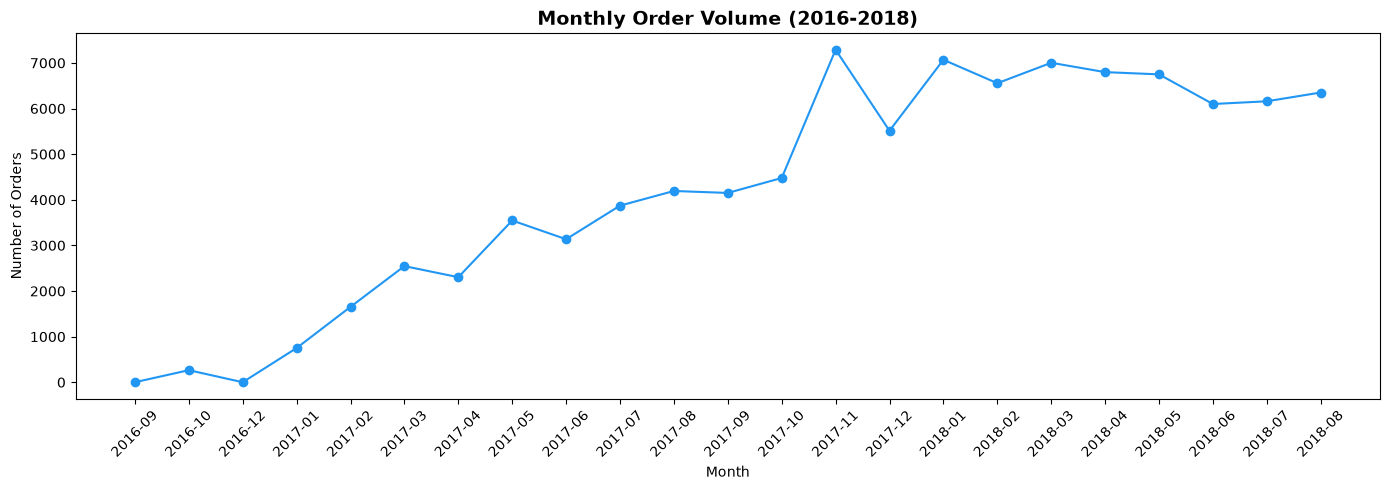

In [12]:
monthly = delivered.groupby('order_month')['order_id'].count().reset_index()
monthly.columns = ['month', 'order_count']

plt.figure(figsize=(14, 5))
plt.plot(monthly['month'].astype(str), monthly['order_count'], marker='o', color='#2196F3')
plt.xticks(rotation=45)
plt.title('Monthly Order Volume (2016-2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('monthly_orders.png', dpi=150)
plt.show()

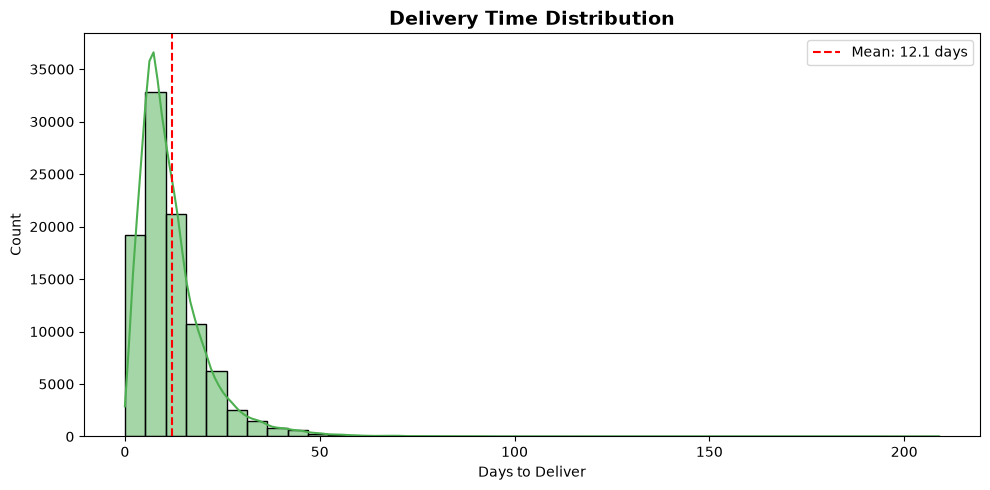

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(delivered['delivery_days'].dropna(), bins=40, kde=True, color='#4CAF50')
plt.axvline(delivered['delivery_days'].mean(), color='red', linestyle='--',
            label=f"Mean: {delivered['delivery_days'].mean():.1f} days")
plt.title('Delivery Time Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Days to Deliver')
plt.legend()
plt.tight_layout()
plt.savefig('delivery_distribution.png', dpi=150)
plt.show()

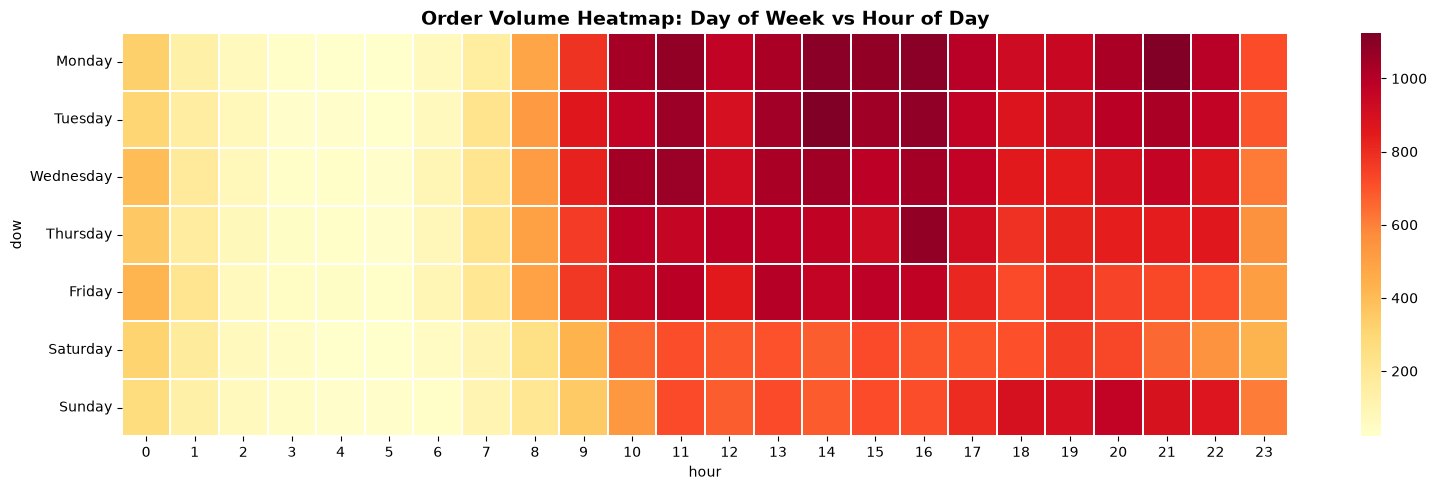

In [14]:
orders['dow'] = orders['order_purchase_timestamp'].dt.day_name()
orders['hour'] = orders['order_purchase_timestamp'].dt.hour

heatmap_data = orders.groupby(['dow', 'hour'])['order_id'].count().unstack()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3)
plt.title('Order Volume Heatmap: Day of Week vs Hour of Day', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_orders.png', dpi=150)
plt.show()

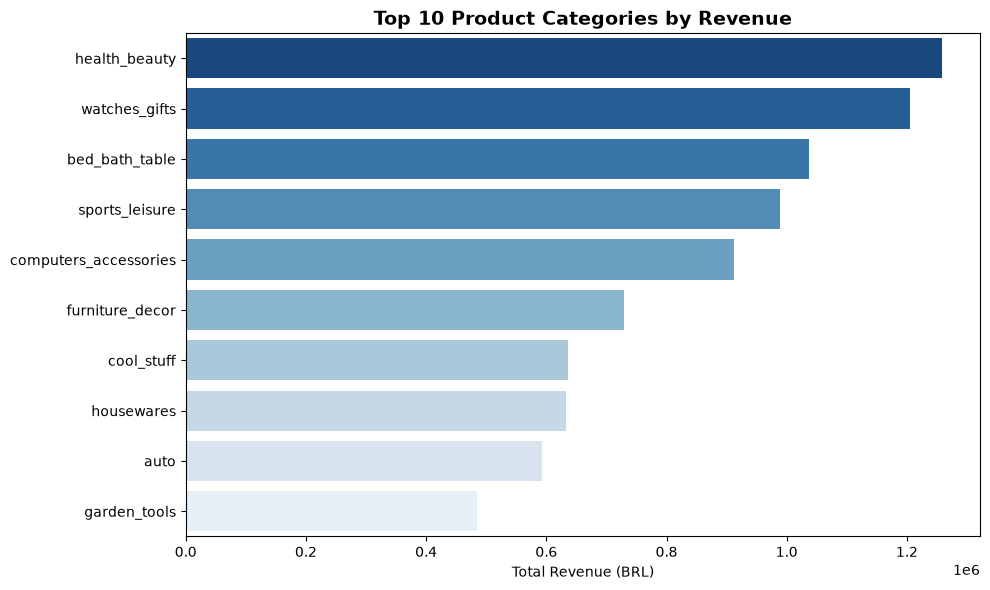

In [15]:
items_prod = order_items.merge(products[['product_id', 'product_category_name']], on='product_id')
items_prod = items_prod.merge(translation, on='product_category_name', how='left')
items_prod['category_en'] = items_prod['product_category_name_english'].fillna(
    items_prod['product_category_name'])

top_cats = items_prod.groupby('category_en')['price'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='price', y='category_en', data=top_cats, palette='Blues_r')
plt.title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150)
plt.show()